In [1]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[Sx_full / N, Sz_full / N],args=args)

    op_Sx_avg = np.average(result.expect[0])
    op_Sz_avg = np.average(result.expect[1])

    return op_Sx_avg, op_Sz_avg



100%|██████████| 30/30 [02:23<00:00,  4.80s/it]


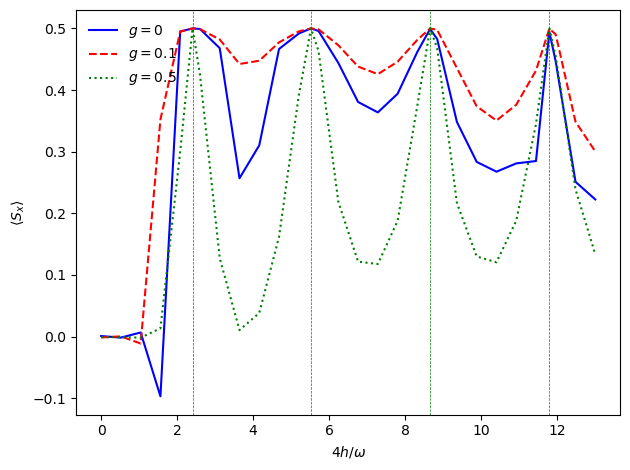

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 10
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omega = 90

hs = np.linspace(0, 13, 26) * omega / 4
hs = np.sort(np.append(hs, frz * omega / 4))

# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 20 + 1)
opts = Options(nsteps =1e6)

gvals = [0, 0.1, 0.5]
colors = ['blue', 'red', 'green']
styles = ['-', '--', ':']

for g, c, s  in zip(gvals, colors, styles):
   args_list = [{
    'omega': omega,
    'h0': h0,
    'g': g,
    'tlist': tlist,
    'N': N,
    'n_ph': n_ph,
    'hbar': hbar,
    'omega0': omega0,
    'Jvalue': Jvalue,
    'h':h,
    'opts':opts
    } for h in hs]

  # parallel run

   p = Pool(processes=10)
   results = p.map(run_dynamics_lmg, tqdm(args_list))

   p.close()
   p.join()

   results = np.array(results)
   Sx_avgs = results[:, 0]
   Sz_avgs = results[:, 1]

   # plot
   plt.plot(4*hs/omega, Sx_avgs, color=c, linestyle=s, label=rf'$g={g}$')
#plt.plot(4*hs/omega, Sz_avgs, label=r'$\langle S_z \rangle$')

for i in frz:
    plt.axvline(x=i, ls='--', color='green', lw=0.5)

plt.xlabel(r'$4h / \omega$')
plt.ylabel(r'$\langle S_x \rangle$')
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# FFT

In [5]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[Sx_full / N, Sz_full / N],args=args)

    op_Sx_full = result.expect[0]
    op_Sz_full = result.expect[1]

    return op_Sx_full, op_Sz_full



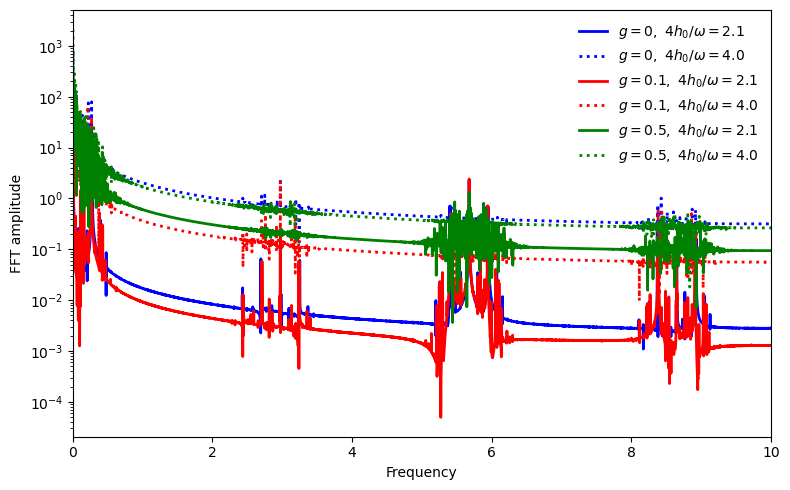

In [6]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)


# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 10
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omega = 90

#hs = np.linspace(0, 13, 26) * omega / 4
#hs = np.sort(np.append(hs, frz * omega / 4))

# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 20 + 1)
opts = Options(nsteps =1e6)
dt = tlist[1] - tlist[0]
# near freezing points  
hs_1 = 2.1 * omega / 4

# away from freezing points 
hs_2 = 4 * omega / 4

hs = [hs_1, hs_2]

gvals = [0, 0.1, 0.5]
colors = ['blue', 'red', 'green']

plt.figure(figsize=(8,5))

for g, c  in zip(gvals, colors):
   signals = []
   for h in hs:
       args = {
      'omega': omega,
      'h0': h0,
      'g': g,
      'tlist': tlist,
      'N': N,
      'h':h,
      'n_ph': n_ph,
      'hbar': hbar,
      'omega0': omega0,
      'Jvalue': Jvalue,
      'opts':opts
         }

  # parallel run
  
       Sx_t, Sz_t = run_dynamics_lmg(args)
       signals.append(Sx_t)

 # Save Data
   np.save(f'Sx_fft_data_g_{g}.npy', signals) 

# FFT

   styles = ['-', ':']
   for signal, h, s in zip(signals, hs, styles):

        signal = signal - np.mean(signal)

        fft_signal = np.abs(np.fft.fft(signal))

        freq = np.fft.fftfreq(len(signal),d=dt)

        pos = freq > 0
        x = 4*h/omega
        plt.plot(
            freq[pos],
            fft_signal[pos],
            color=c,
            linestyle=s,
            linewidth=2,
            label=rf'$g={g},\ 4h_0/\omega={x:.1f}$')

# =====================================================
# Plot settings
# =====================================================

plt.xlim(0,10)

plt.xlabel('Frequency')

plt.ylabel('FFT amplitude')

plt.yscale('log')

plt.legend(frameon=False)

plt.tight_layout()

plt.show() 



In [1]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx, n_photon


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']
    opts = args['opts']

    H0, H1, H2, H_int, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[n_photon],args=args,options=opts)

    #op_Sx_avg = np.average(result.expect[0])
    #op_Sz_avg = np.average(result.expect[1])
    op_n_photon = result.expect[0]

    return op_n_photon



100%|██████████| 1/1 [00:00<00:00, 92.01it/s]


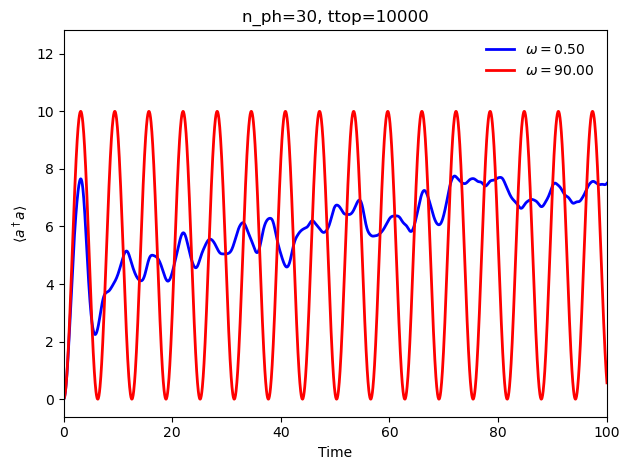

In [2]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 30
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omegas = [0.5,90]
x = 2.40
colors = ['blue', 'red']


# time
ttop = 10000
tlist = np.linspace(0, ttop, ttop * 20 + 1)
opts = Options(nsteps =1e6)

#styles = ['-', '--']

for omega,color in zip(omegas, colors):
    
        h = x * omega / 4
        args = {'omega': omega,'h0': h0,'g': g,'tlist': tlist,'N': N,'n_ph': n_ph,'hbar': hbar,'omega0': omega0,'Jvalue': Jvalue,'h':h,'opts':opts}
        
        #parallel run

        p = Pool(processes=10)
        n_photon_t = p.map(run_dynamics_lmg,tqdm([args]))

        p.close()
        p.join()

        n_photon_t = n_photon_t[0]
        
        np.save(f'N_{N}_n_ph_{n_ph}_g_{g:.2f}_omega_{omega:.2f}_x_{x:.2f}.npy',n_photon_t)
    
        # plot
        plt.plot(tlist,n_photon_t,color=color,linestyle='-',linewidth=2,label=rf'$\omega={omega:.2f}$')


  
plt.xlabel('Time')
plt.xlim(0,100)

plt.ylabel(r'$\langle a^\dagger a \rangle$')
plt.title(f'n_ph={n_ph}, ttop={ttop}')

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(f'photon_number_dynamics_n_ph={n_ph}, ttop={ttop}.png',dpi=300,bbox_inches='tight')

plt.show()

  

 

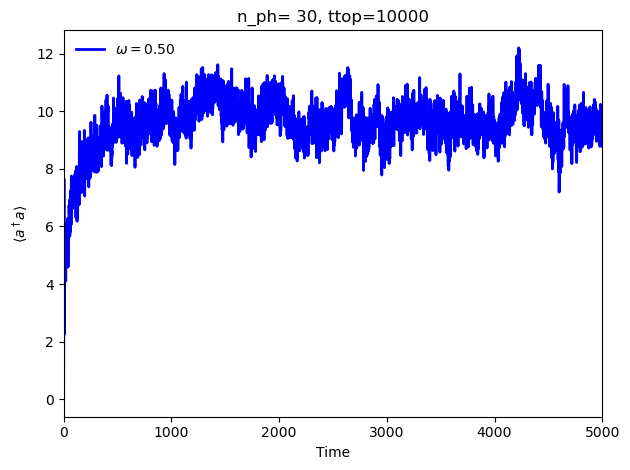

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# parameters
# ============================================

omegas = [0.5]
N = 10
n_ph = 30
g = 0.5
hbar = 1.0
omega0 = 1.0
x = 2.40    

colors = ['blue', 'red']

# ============================================
# recreate tlist
# ============================================

ttop = 10000

tlist = np.linspace(0, ttop, ttop*20 + 1)

# ============================================
# plot
# ============================================


# ============================================
# load and plot
# ============================================

for omega, c in zip(omegas, colors):

    # ----------------------------------------
    # load data
    # ----------------------------------------

    n_photon_t = np.load(f'N_{N}_n_ph_{n_ph}_g_{g:.2f}_omega_{omega:.2f}_x_{x:.2f}.npy')

    # ----------------------------------------


    # ----------------------------------------
    # plot
    # ----------------------------------------

    plt.plot(tlist,n_photon_t,color=c,linewidth=2,label=rf'$\omega={omega:.2f}$')

# ============================================
# plot settings
# ============================================

plt.xlabel('Time')

plt.ylabel(r'$\langle a^\dagger a \rangle$')

plt.title(rf'n_ph= {n_ph}, ttop={ttop}')

plt.xlim(0,5000)

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(f'photon_number_dynamics_n_ph={n_ph}, ttop={ttop}.png',dpi=300,bbox_inches='tight')

plt.show()     


In [2]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx, n_photon


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[n_photon],args=args)

    #op_Sx_avg = np.average(result.expect[0])
    #op_Sz_avg = np.average(result.expect[1])
    op_n_photon = result.expect[0]

    return op_n_photon



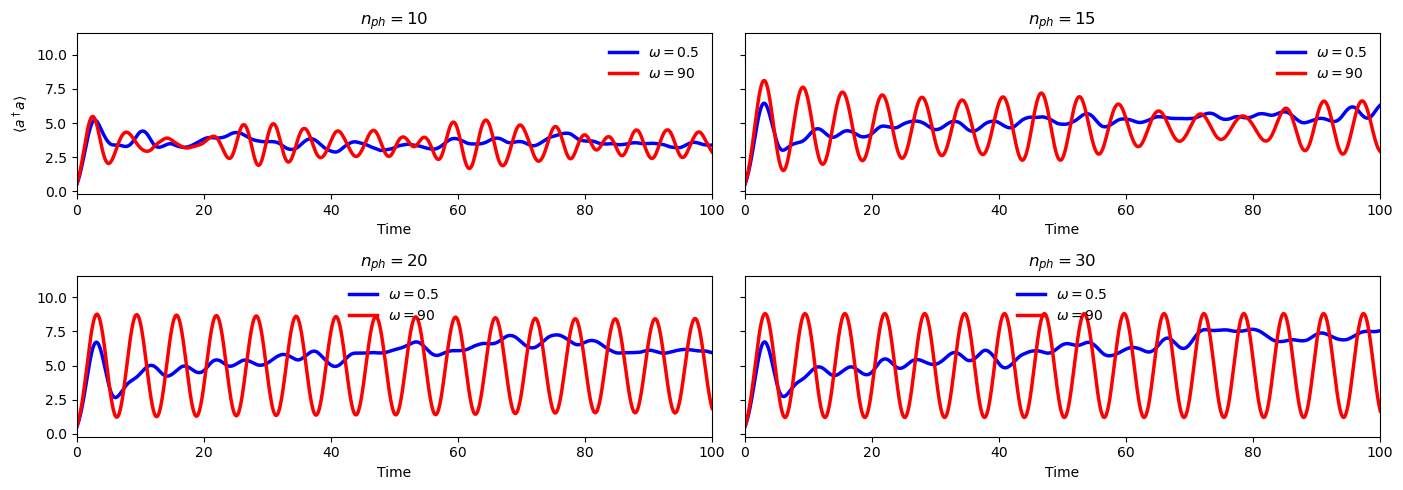

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing p,oints
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omegas = [0.5,90]
x = 2.40
colors = ['blue', 'red']
nph_vals = [10,15,20,30]

fig, axes = plt.subplots(2,2,figsize=(14,5),sharey=True)
axes = axes.flatten()



# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 20 + 1)
opts = Options(nsteps =1e6)

#styles = ['-', '--']

for ax, n_ph in zip(axes, nph_vals):
        for omega,color in zip(omegas, colors):
        
                h = x * omega / 4
                args = {
                'omega': omega,
                'h0': h0,
                'g': g,
                'tlist': tlist,
                'N': N,
                'n_ph': n_ph,
                'hbar': hbar,
                'omega0': omega0,
                'Jvalue': Jvalue,
                'h':h,
                'opts':opts
                }
                n_photon_t = run_dynamics_lmg(args)
        
                # plot
                window = 50

                smooth_n = np.convolve(n_photon_t,np.ones(window)/window,mode='same')

                # -------------------------------------------------
                # save data
                # -------------------------------------------------

                np.savez(f'photon_omega_{omega}_nph_{n_ph}.npz',tlist=tlist,n_t=n_photon_t)

                # -------------------------------------------------
                # plot
                # -------------------------------------------------

                ax.plot(tlist,smooth_n,color=color,linestyle='-',linewidth=2.5,label=rf'$\omega={omega}$')
   
        # =================================================
        # subplot settings
        # =================================================

        ax.set_title(rf'$n_{{ph}}={n_ph}$')

        ax.set_xlabel('Time')

        ax.set_xlim(0,100)

        ax.legend(frameon=False)

# =====================================================
# common y-label
# =====================================================

axes[0].set_ylabel(r'$\langle a^\dagger a \rangle$')

plt.tight_layout()
  
# =====================================================
# save figure
# =====================================================

omega_string = '_'.join(map(str, omegas))

nph_string = '_'.join(map(str, nph_vals))

plt.savefig(f'photon_dynamics_omegas_{omega_string}_nph_{nph_string}.png',dpi=300,bbox_inches='tight')

plt.show()

  

 